In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('Pokemon.csv')

In [3]:
df.shape

(800, 13)

In [4]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [5]:
df.tail()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True
799,721,Volcanion,Fire,Water,600,80,110,120,130,90,70,6,True


In [6]:
df.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [7]:
df['Type 2'] = df['Type 2'].fillna('unknown')

In [8]:
df.isnull().sum()

#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [10]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [11]:
df['Legendary'] = df['Legendary'].astype(str).map({'True': 1, 'False': 0})

In [12]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,0
4,4,Charmander,Fire,unknown,309,39,52,43,60,50,65,1,0


In [13]:
df.tail()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,1
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,1
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,1
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,1
799,721,Volcanion,Fire,Water,600,80,110,120,130,90,70,6,1


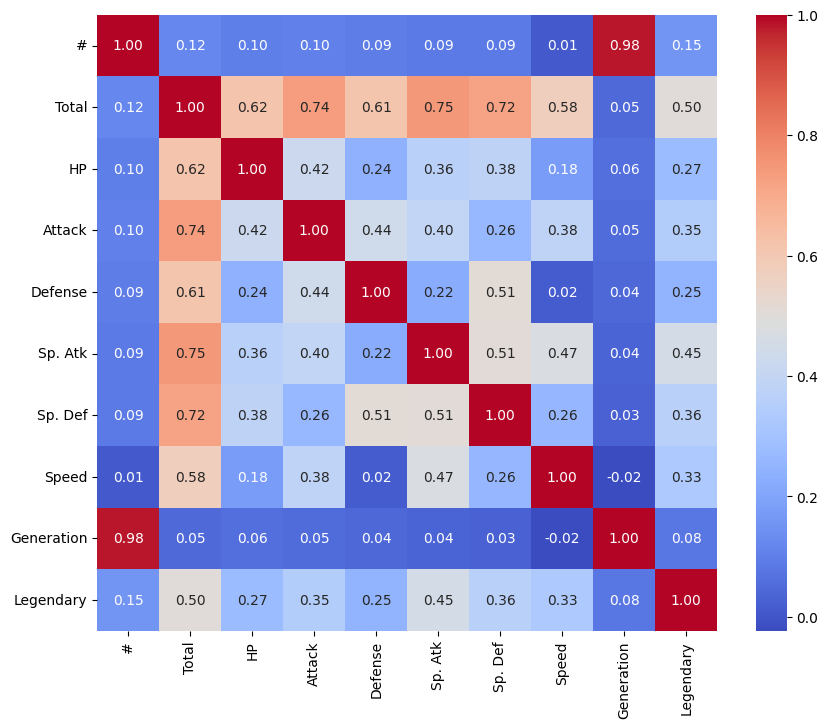

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


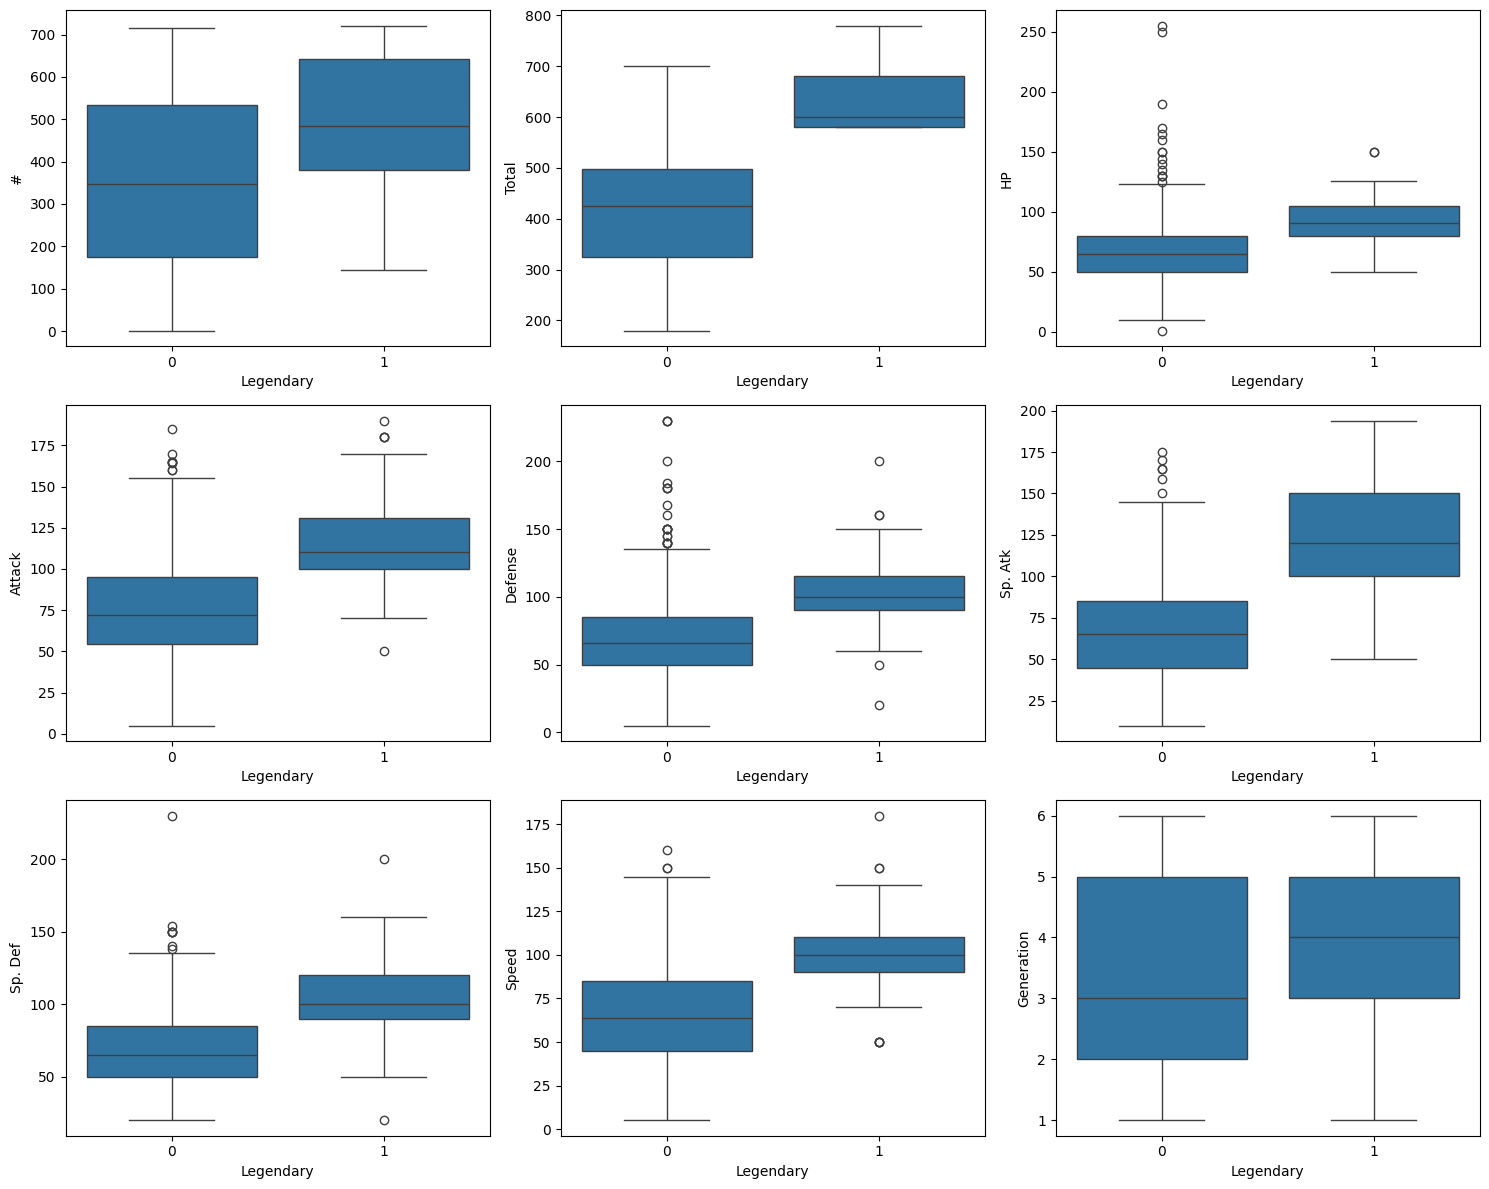

In [15]:
features = [c for c in df.select_dtypes(include='number').columns if c != 'Legendary']

n_cols = 3
n_rows = -(-len(features) // n_cols) 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(x='Legendary', y=col, data=df, ax=ax)

for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


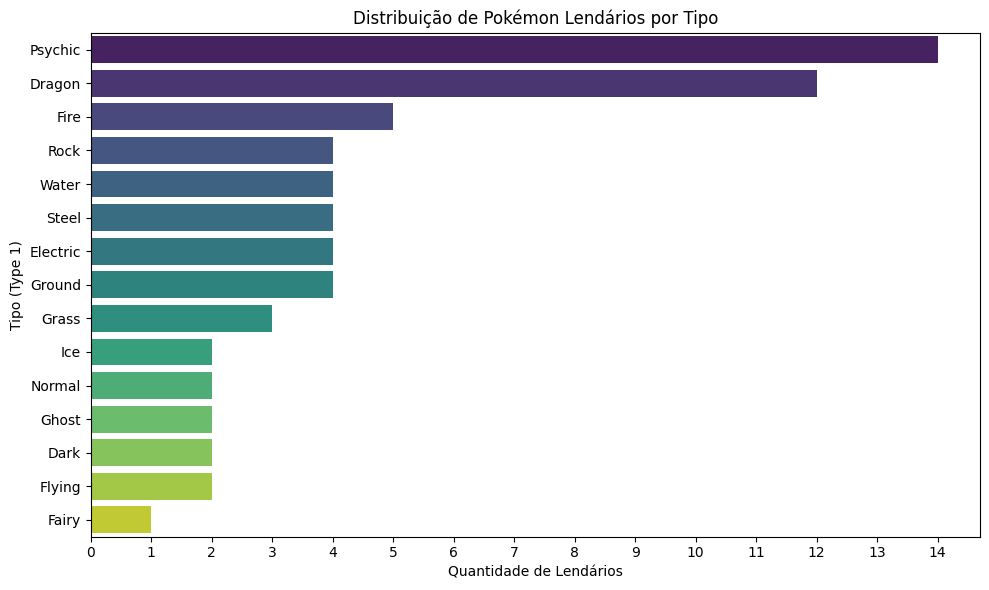

In [16]:
# Quantidade de Pokémon Lendários por tipo (Type 1)
lendarios_por_tipo = df[df['Legendary'] == 1]['Type 1'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=lendarios_por_tipo.values, y=lendarios_por_tipo.index, hue=lendarios_por_tipo.index,
            palette='viridis', legend=False)
plt.xlabel('Quantidade de Lendários')
plt.ylabel('Tipo (Type 1)')
plt.title('Distribuição de Pokémon Lendários por Tipo')
plt.xticks(range(0, lendarios_por_tipo.max() + 1))
plt.tight_layout()
plt.show()


In [17]:
X = df.drop(['Legendary', 'Type 1', 'Type 2', 'Name'], axis=1)
y = df['Legendary']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
print(y.isnull().sum())
print(y.unique())


0
[0 1]


In [19]:
param_grid_rf = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6, 8]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_rf.fit(X_treino, y_treino)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")


Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.2s
[CV] END max_depth=10, min_

F1 Score Random Forest: 83.33%
Taxa de Erro: 2.50%



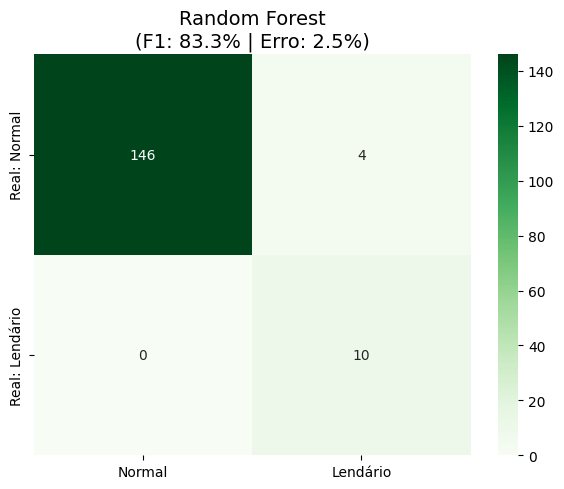

In [20]:
modelo = RandomForestClassifier(**grid_rf.best_params_, random_state=42, n_jobs=-1)

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

f1 = f1_score(y_teste, previsoes)
acc = accuracy_score(y_teste, previsoes)
print(f"F1 Score Random Forest: {f1 * 100:.2f}%")
print(f"Taxa de Erro: {(1 - acc) * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_rf = confusion_matrix(y_teste, previsoes)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Lendário'], yticklabels=['Real: Normal', 'Real: Lendário'])
plt.title(f'Random Forest\n(F1: {f1*100:.1f}% | Erro: {(1-acc)*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()


In [21]:
param_grid_xgb = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'subsample': [0.8, 1.0, 1.2],
    'colsample_bytree': [0.8, 1.0, 1.2] 
}

xgb_base = XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_xgb.fit(X_treino, y_treino)

print(f"Melhores Parâmetros XGB: {grid_xgb.best_params_}")

Fitting 3 folds for each of 720 candidates, totalling 2160 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.2; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.2; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   2.1s
[CV] END

/home/vcollares/.venv/lib64/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1200 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/vcollares/.venv/lib64/python3.12/site-packages/xgboost/sklearn.py", line 1806, in fit
    self._Booster = train(
      

Melhores Parâmetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.5, 'max_depth': 6, 'n_estimators': 700, 'subsample': 0.8}


F1 Score XGBoost: 86.96%
Taxa de Erro: 1.88%



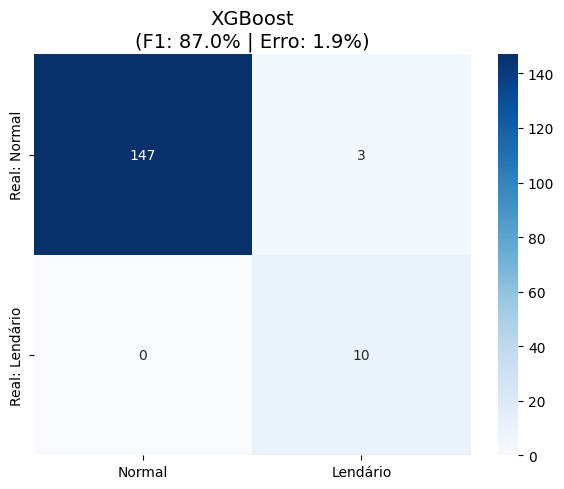

In [22]:
modelo_xgb = XGBClassifier(**grid_xgb.best_params_, random_state=42, n_jobs=-1)

modelo_xgb.fit(X_treino, y_treino)

previsoes_xgb = modelo_xgb.predict(X_teste)

f1_xgb = f1_score(y_teste, previsoes_xgb)
acc_xgb = accuracy_score(y_teste, previsoes_xgb)
print(f"F1 Score XGBoost: {f1_xgb * 100:.2f}%")
print(f"Taxa de Erro: {(1 - acc_xgb) * 100:.2f}%\n")

plt.figure(figsize=(6, 5))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Lendário'], yticklabels=['Real: Normal', 'Real: Lendário'])
plt.title(f'XGBoost\n(F1: {f1_xgb*100:.1f}% | Erro: {(1-acc_xgb)*100:.1f}%)', fontsize=14)
plt.tight_layout()
plt.show()


In [23]:

# Predições no conjunto de TREINO
prev_treino_rf  = modelo.predict(X_treino)
prev_treino_xgb = modelo_xgb.predict(X_treino)

f1_treino_rf   = f1_score(y_treino, prev_treino_rf)
acc_treino_rf  = accuracy_score(y_treino, prev_treino_rf)
f1_treino_xgb  = f1_score(y_treino, prev_treino_xgb)
acc_treino_xgb = accuracy_score(y_treino, prev_treino_xgb)

f1_teste_rf   = f1_score(y_teste, previsoes)
acc_teste_rf  = accuracy_score(y_teste, previsoes)
f1_teste_xgb  = f1_score(y_teste, previsoes_xgb)
acc_teste_xgb = accuracy_score(y_teste, previsoes_xgb)

print('=' * 52)
print(f'{'':>20} {'TREINO':>10} {'TESTE':>10}')
print('=' * 52)
print(f'{'RF  — F1 Score':>20} {f1_treino_rf*100:>9.2f}% {f1_teste_rf*100:>9.2f}%')
print(f'{'RF  — Acurácia':>20} {acc_treino_rf*100:>9.2f}% {acc_teste_rf*100:>9.2f}%')
print('-' * 52)
print(f'{'XGB — F1 Score':>20} {f1_treino_xgb*100:>9.2f}% {f1_teste_xgb*100:>9.2f}%')
print(f'{'XGB — Acurácia':>20} {acc_treino_xgb*100:>9.2f}% {acc_teste_xgb*100:>9.2f}%')
print('=' * 52)
print()
print(f'Diferença RF  (treino - teste) F1:  {(f1_treino_rf  - f1_teste_rf)*100:+.2f}%')
print(f'Diferença XGB (treino - teste) F1:  {(f1_treino_xgb - f1_teste_xgb)*100:+.2f}%')
print()
print('Interpretação:')
print('  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)')
print('  Diferença grande  (> 10%) => possível overfitting')


                         TREINO      TESTE
      RF  — F1 Score     98.21%     83.33%
      RF  — Acurácia     99.69%     97.50%
----------------------------------------------------
      XGB — F1 Score    100.00%     86.96%
      XGB — Acurácia    100.00%     98.12%

Diferença RF  (treino - teste) F1:  +14.88%
Diferença XGB (treino - teste) F1:  +13.04%

Interpretação:
  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)
  Diferença grande  (> 10%) => possível overfitting
